# Two-Layer Teacher Temperature LR Sweep

We define an energy function $T: \mathbb{R}^{d} \to \mathbb{R}^{k}$, where $T$ takes the form
$$
T(x) = \frac{1}{\gamma n^{a_{2}}}W^{2} g\left( \frac{1}{d^{a_{1}}}W^{1} x \right),
$$
with (1) $W^2 = G\sqrt{ \Sigma }$ for $G \sim \mathcal{N}(0, n^{-b_{2}} I_{k \times n})$ and $\Sigma \in \mathbb{R}^{n \times n}$ diagonal and deterministic with $\Sigma_{ii} = i^{-2\alpha}$ for some $\alpha > 0$; (2) $W^{1} \sim \mathcal{N}(0, d^{-b_{1}}I_{n \times d})$; and (3) $g \in C^{1}(\mathbb{R})$ acting elementwise. We refer to this as a random sample from the ensemble $(d, n, k, \Sigma)$.

Define $h^{1} =  \frac{1}{\sqrt{ d }}W^{1} x$ and $h^{2} = \gamma T(x)$.

We choose the exponents in the teacher in order to (1) keep the RMS norms of $h^{1}$ and $h^{2}$ order-1 at initialization and to (2) also keep the feature map $\frac{\partial T}{\partial h^{1}}$ with RMS norm $\Theta(1)$. Indeed, for $\alpha \neq \frac{1}{2}$ the space of allowable scalings is
$$
b_{1}=1-2a_{1},\qquad b_{2}=s_{\alpha}-2a_{2}-2c,
$$
where $\gamma = n^{c}$ for $c \geq 0$ and 

$$
s_{\alpha} = \log_{n}\sum_{i = 1}^{n} n^{-2\alpha} \sim 
\begin{cases}
1 - 2 \alpha & \alpha < \frac{1}{2} \\
0 & \alpha > \frac{1}{2}.
\end{cases}
$$
We provisionally consider the easy regime $\alpha > \frac{1}{2}$, and make a choice of scalings that doesn't fully absorb the power exponent of $\gamma$ into $a_{2}$:
$$
\gamma=n^{c},\qquad a_{1}=\frac{1}{2},\qquad b_{1}=0,\qquad a_{2}=\frac{s_{\alpha}-2c}{4} = -\frac{c}{2},\qquad b_{2}=\frac{s_{\alpha}-2c}{2} = -c.
$$

We consider the following experimental procedure:

1. Randomly draw a teacher from the ensemble $(d, n, k, \Sigma)$ and a student from the ensemble $(d, \kappa n, k, I_{n})$.
2. Draw an iid train set $\mathcal{S} := \{(x_i, y_i) : i \in [p]\}$ and an independent iid test set $\mathcal{T} := \{(x'_i, y'_i) : i \in [p]\}$ with $x_i, x'_i \sim \mathcal{N}(0, I_d)$. Sample labels from the $\beta$-inverse temperature Gibbs distribution
$$
P(y = j |x) \propto \exp(\beta T_j(x)).
$$
We use the Gumbel-max trick as necessary to simulate sampling. Every recorded observable that depends on sampled inputs is evaluated separately on train and test.
3. Train the student network using $T$ steps of SGD on the train set. For minibatch SGD, the batch size is $\operatorname{round}(p^{\delta})$, unless an explicit `minibatch_size` override is supplied.

We sweep this experimental procedure over $\beta$ in log space, from $\beta = 10^{-3}$ to $10^{2}$.

First, let's find the optimal learning rate for each $\beta$ in the non-saturated transition regime. Choose $d = k = 100$, $n = 3d = 300$, $\alpha = \frac{3}{4}$, and $p = 4n = 1200$. We sweep ten log-spaced $\beta$ values from $1$ to $20$ and train full-batch runs for 2000 steps.

We compare full-batch gradient descent, Adam, and Muon. Best learning rate is selected by final `test_xent`, then plotted as a function of $\beta$ for each optimizer.


In [1]:
import sys
from pathlib import Path

# Add parent directory to path to import two_layer_experiment
sys.path.insert(0, str(Path('.').resolve().parent))

import matplotlib.pyplot as plt
import pandas as pd

from two_layer_experiment.results import best_learning_rates, load_results
from two_layer_experiment.plotting import pareto_plot

run_root = Path('../runs/beta_transition_lr_sweep')
optimizer_order = ['gd', 'adam', 'muon']
optimizer_labels = {'gd': 'GD', 'adam': 'Adam', 'muon': 'Muon'}

frames = []
missing = []
for optimizer in optimizer_order:
    runs_dir = run_root / optimizer
    if not (runs_dir / 'lr_sweep_results.csv').exists():
        missing.append(str(runs_dir))
        continue
    df_optimizer = load_results(runs_dir)
    df_optimizer['optimizer'] = optimizer
    frames.append(df_optimizer)

if missing:
    raise FileNotFoundError(
        'Missing transition sweep results. Run `sbatch slurm/run_beta_transition_optimizers.sbatch` first. '
        f'Missing: {missing}'
    )

df = pd.concat(frames, ignore_index=True)
best = best_learning_rates(df, metric='test_xent')
modes = list(df['mode'].drop_duplicates())
best[['optimizer', 'mode', 'beta', 'lr', 'test_xent']]


/tmp/ipykernel_4183735/1331496729.py:8: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


,optimizer,mode,beta,lr,test_xent
0,adam,population,1.000000,0.000100,4.885868
1,adam,population,1.394951,0.000100,4.724309
2,adam,population,1.945888,0.000100,4.452356
3,adam,population,2.714418,0.000100,4.162813
4,adam,population,3.786479,0.000215,3.617143
5,adam,population,5.281952,0.000215,3.215712
6,adam,population,7.368063,0.000215,3.028005
7,adam,population,10.278085,0.000215,2.911992
8,adam,population,14.337423,0.000215,2.840588
9,adam,population,20.000000,0.000215,2.859201


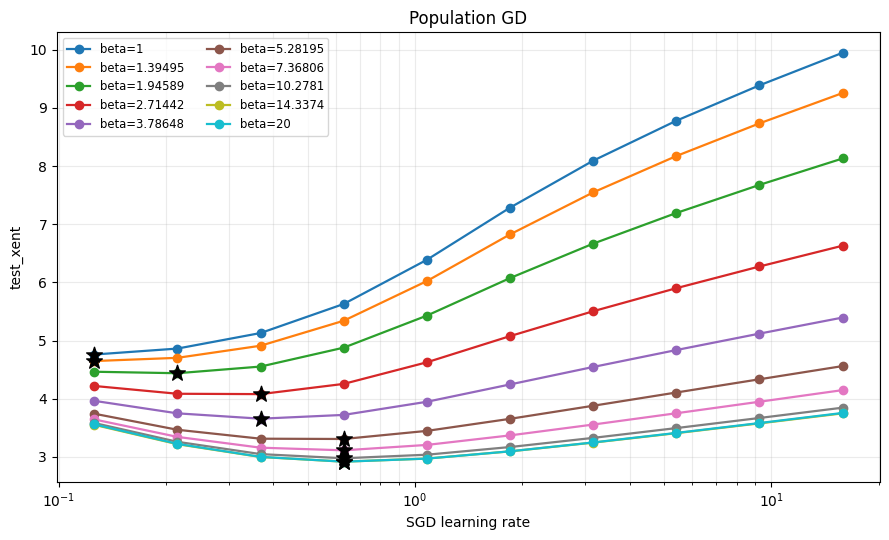

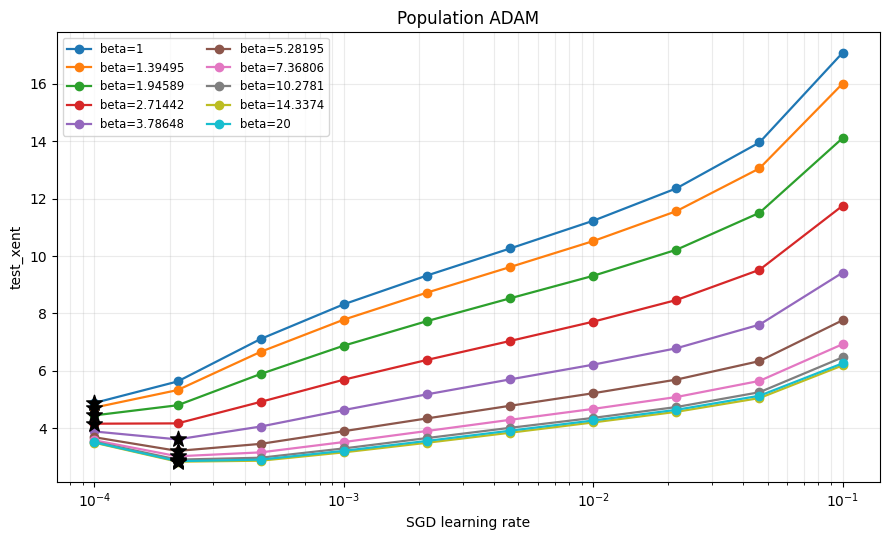

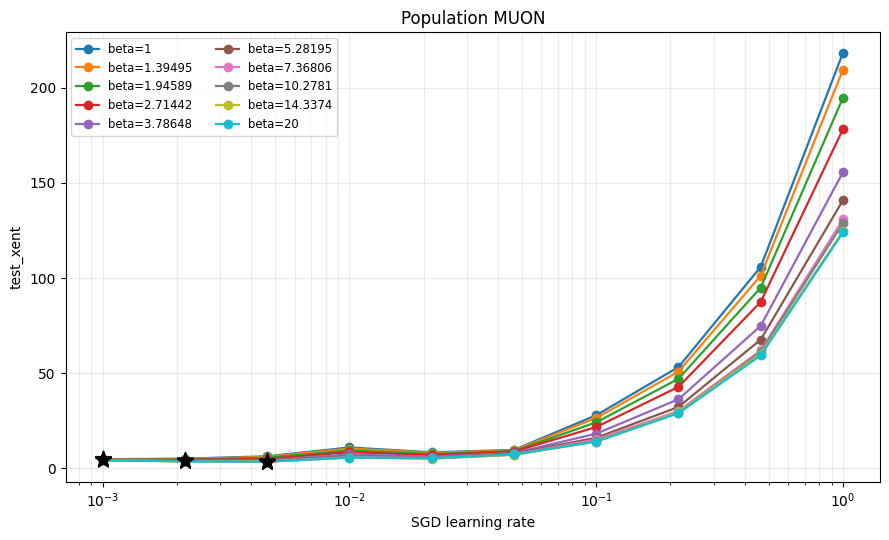

In [2]:
for optimizer in optimizer_order:
    for mode in modes:
        fig, ax = plt.subplots(figsize=(9, 5.5))
        pareto_plot(df, mode, ax=ax, metric='test_xent', optimizer=optimizer)
        fig.tight_layout()
        fig.savefig(run_root / f'pareto_{optimizer}_{mode}_test_xent.png', dpi=180)
        plt.show()


In [3]:
def best_lr_timeseries(df, best, optimizer, mode):
    rows = []
    subset = best[(best['optimizer'] == optimizer) & (best['mode'] == mode)]
    for _, row in subset.iterrows():
        rows.append(
            df[
                (df['optimizer'] == optimizer)
                & (df['mode'] == mode)
                & (df['beta'] == row['beta'])
                & (df['lr'] == row['lr'])
            ]
        )
    return pd.concat(rows, ignore_index=True)

def plot_metric_over_time(ts, metric, optimizer, mode):
    fig, ax = plt.subplots(figsize=(9, 5.2))
    for beta, group in ts.groupby('beta', sort=True):
        group = group.sort_values('step')
        ax.plot(group['step'], group[metric], marker='o', linewidth=1.5, label=f'beta={beta:g}')
    ax.set_title(f'{optimizer_labels[optimizer]} {mode}: {metric} at best final test-xent LR')
    ax.set_xlabel('step')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.25)
    ax.legend(ncols=2, fontsize='small')
    fig.tight_layout()
    fig.savefig(run_root / f'time_{optimizer}_{mode}_{metric}.png', dpi=180)
    return fig

def plot_student_teacher_norm(ts, student_metric, teacher_metric, optimizer, mode):
    fig, ax = plt.subplots(figsize=(9, 5.2))
    for beta, group in ts.groupby('beta', sort=True):
        group = group.sort_values('step')
        ax.plot(group['step'], group[student_metric], marker='o', linewidth=1.5, label=f'beta={beta:g}')
        ax.plot(group['step'], group[teacher_metric], linestyle='--', linewidth=1.3, color='red', alpha=0.75)
    ax.set_title(f'{optimizer_labels[optimizer]} {mode}: {student_metric} with teacher reference')
    ax.set_xlabel('step')
    ax.set_ylabel(student_metric)
    ax.grid(True, alpha=0.25)
    ax.legend(ncols=2, fontsize='small')
    fig.tight_layout()
    fig.savefig(run_root / f'time_{optimizer}_{mode}_{student_metric}_teacher_overlay.png', dpi=180)
    return fig

time_metrics = [
    'test_xent',
    'train_xent',
    'test_logit_mse',
    'train_logit_mse',
    'test_student_df_dh1_rms',
    'w1_cosine_fro',
]
norm_overlays = [
    ('test_student_h1_rms', 'test_teacher_h1_rms'),
    ('test_student_h2_rms', 'test_teacher_h2_rms'),
]


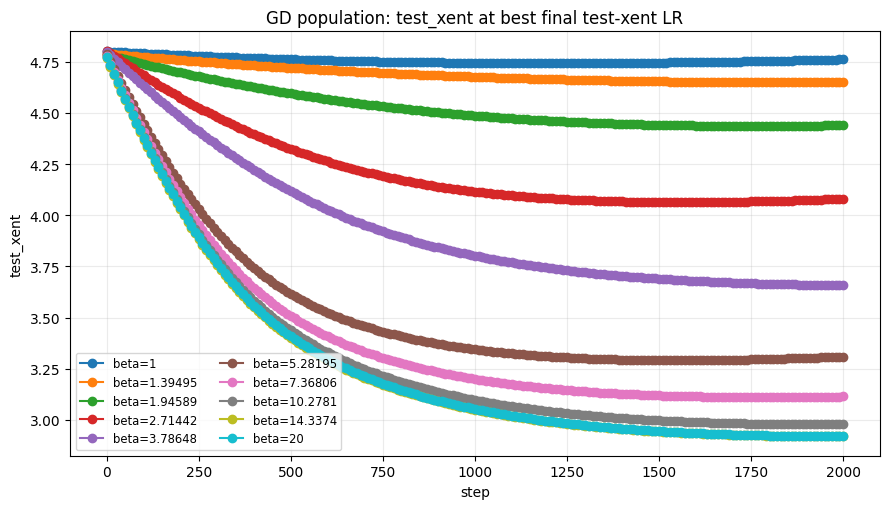

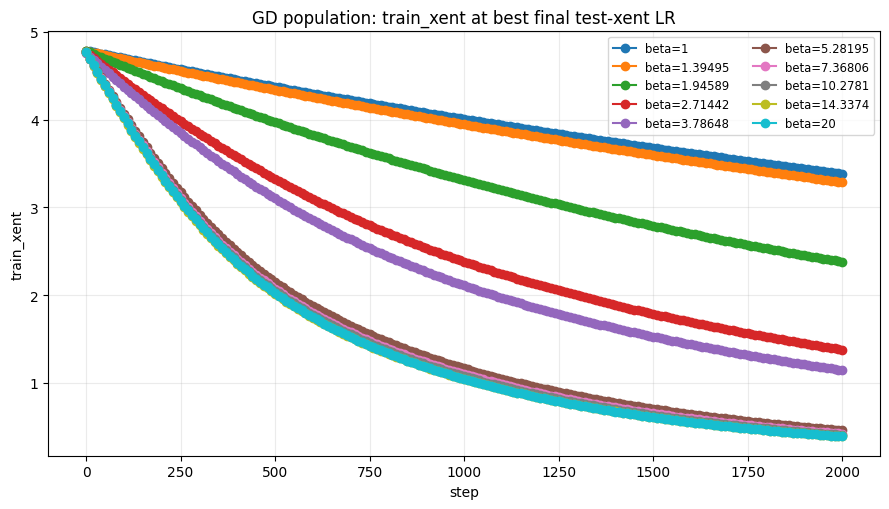

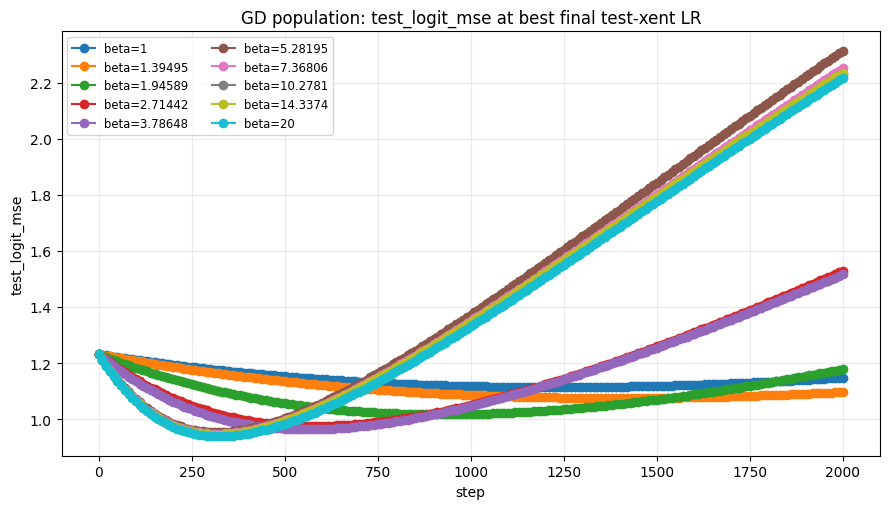

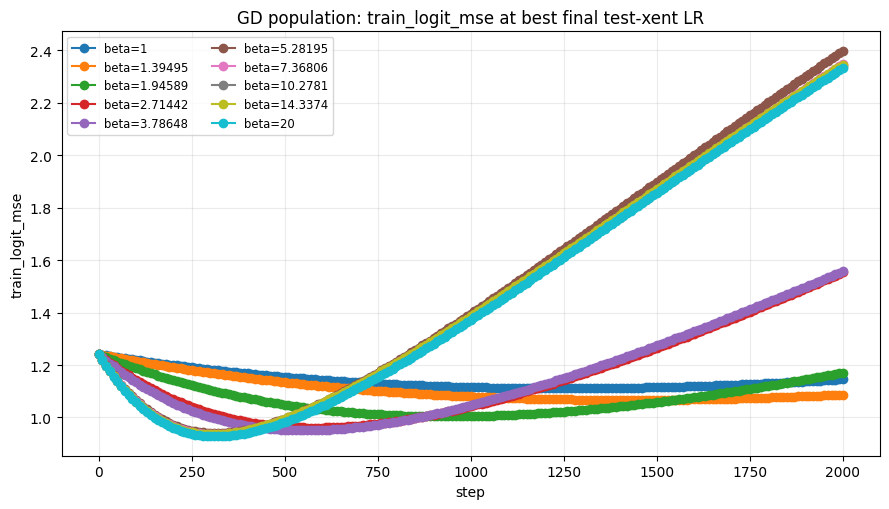

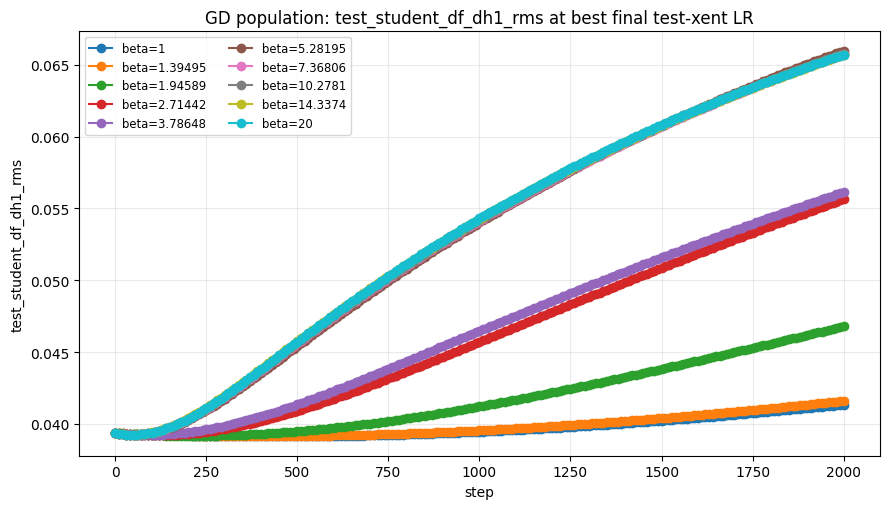

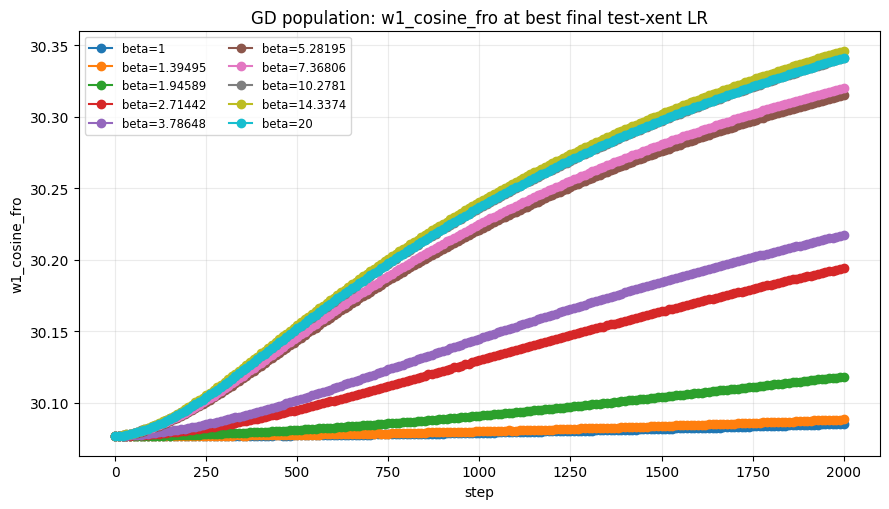

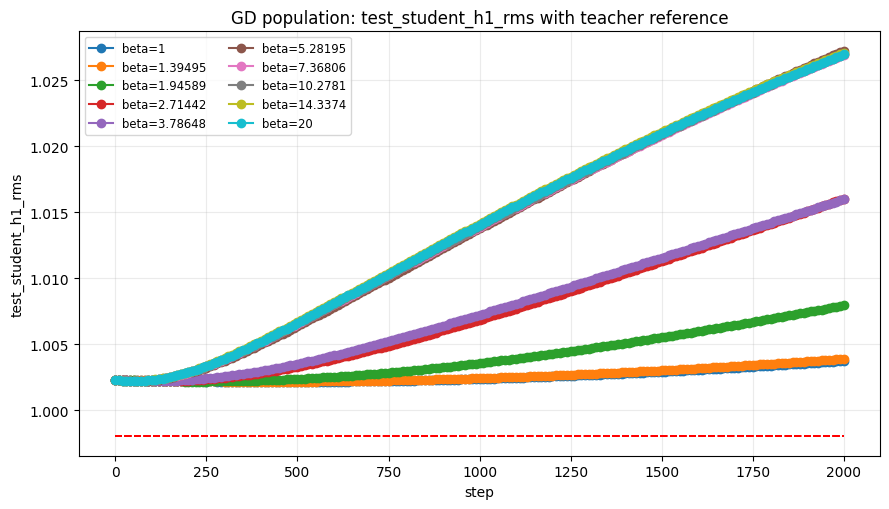

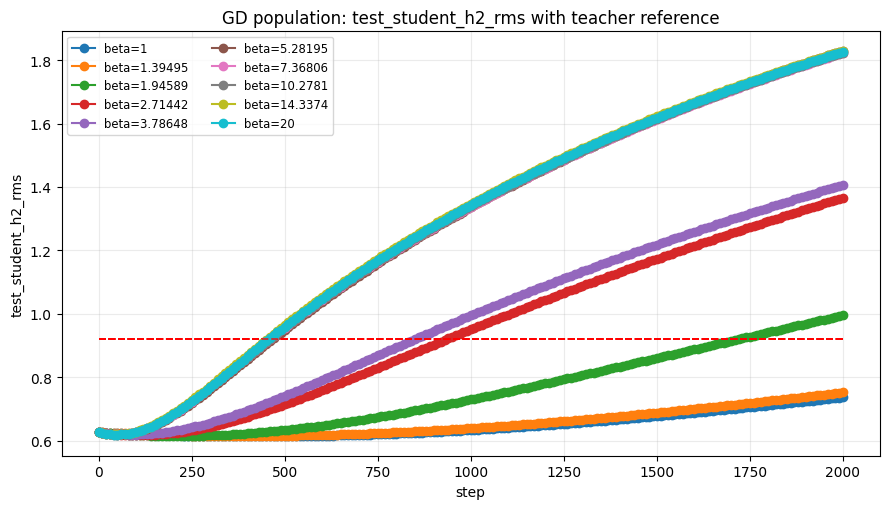

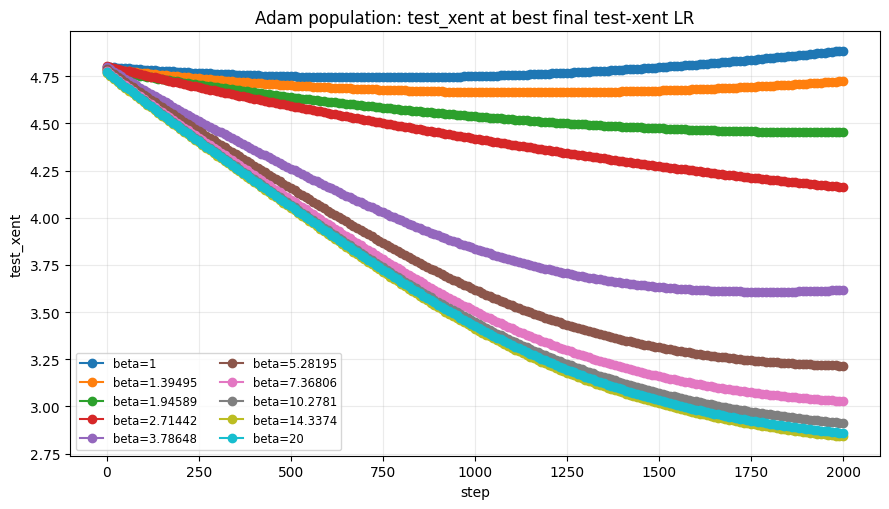

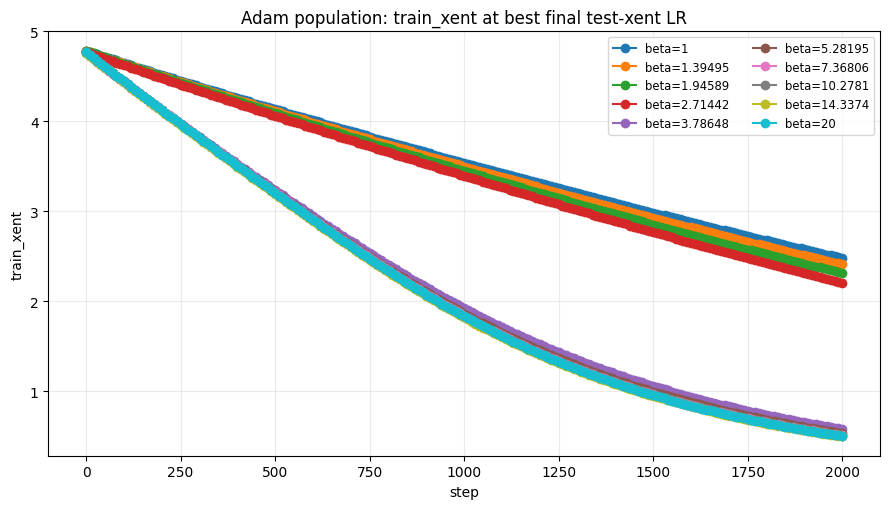

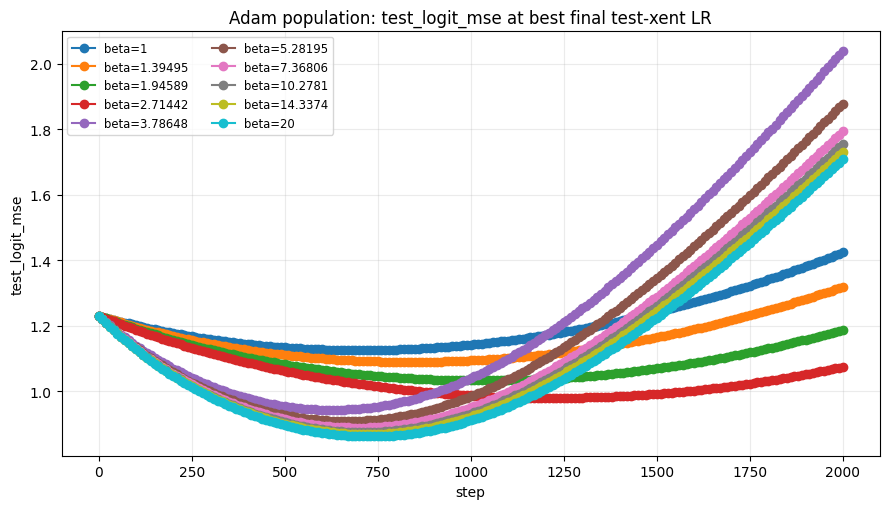

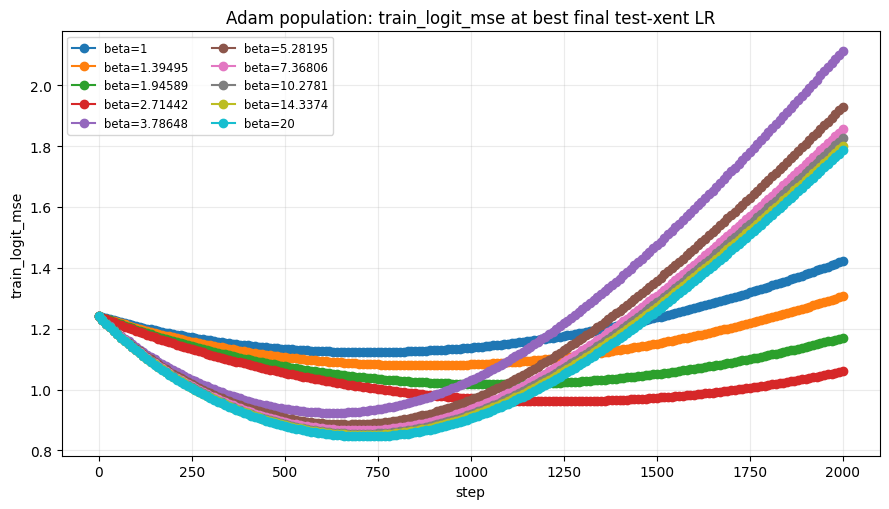

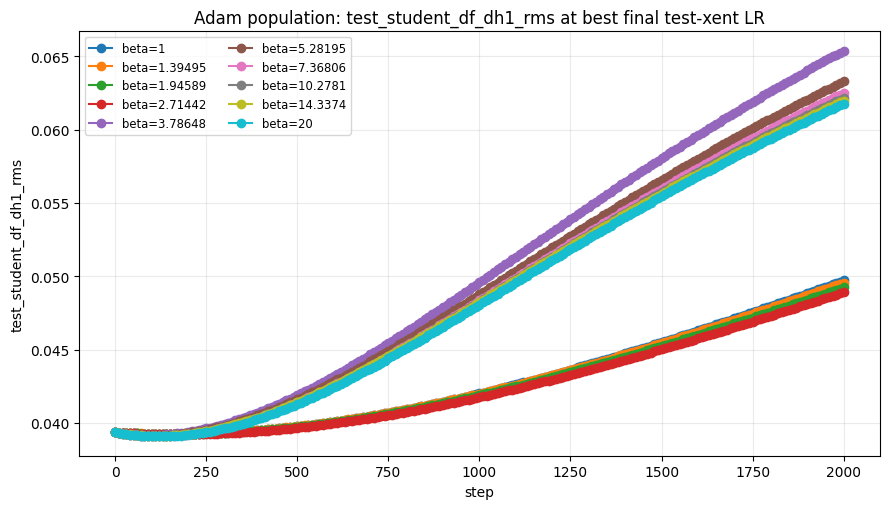

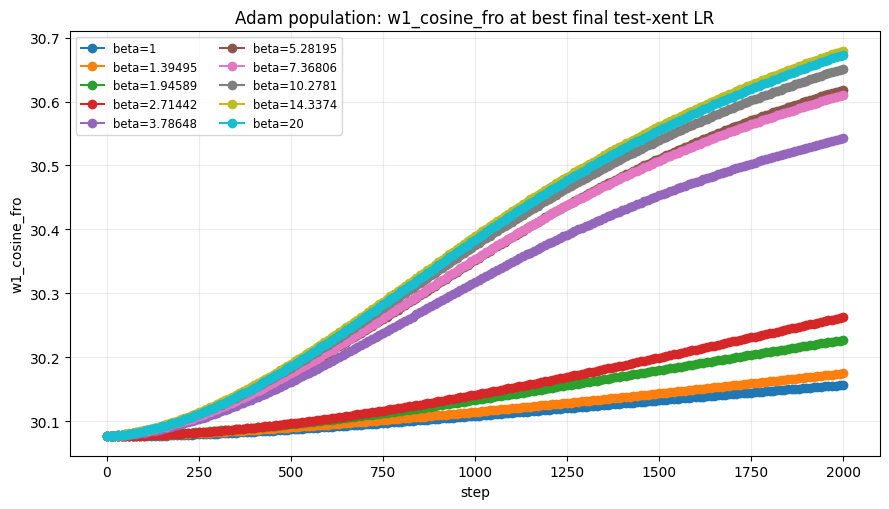

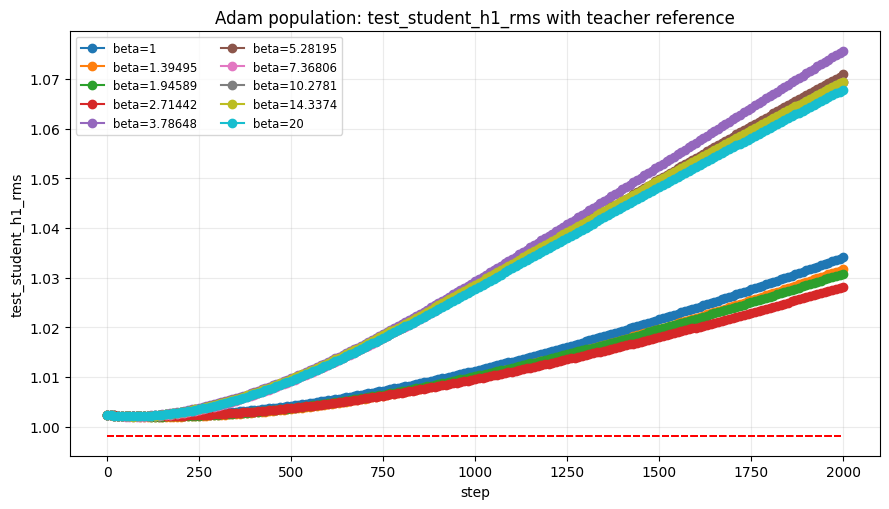

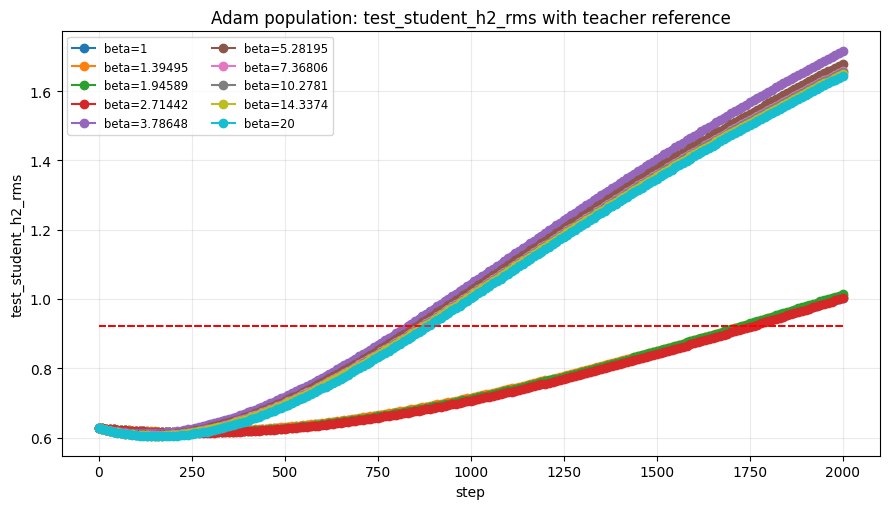

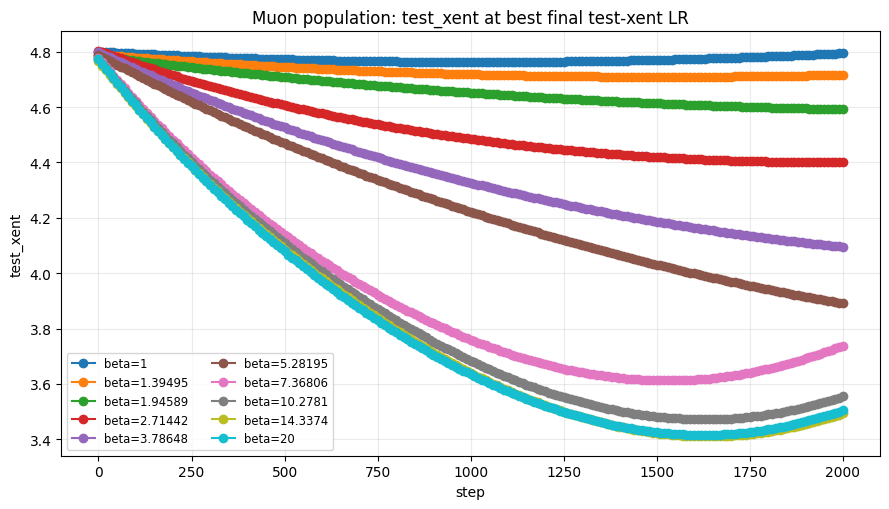

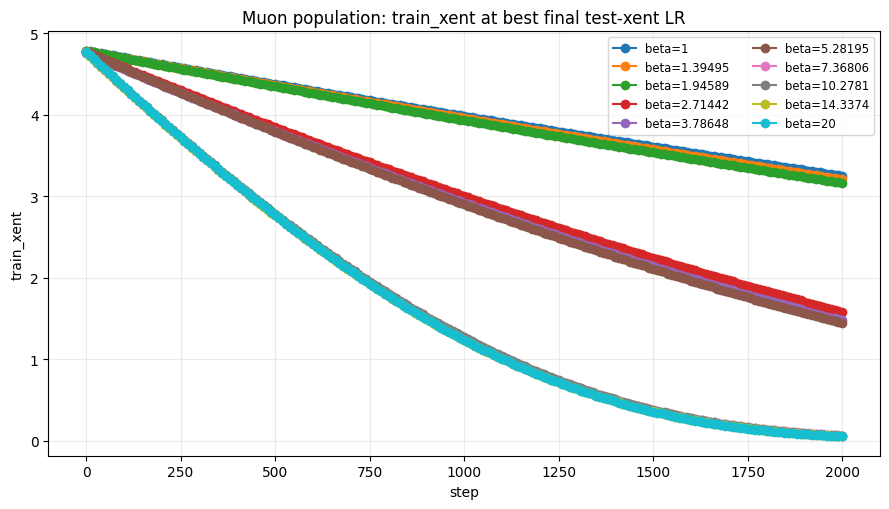

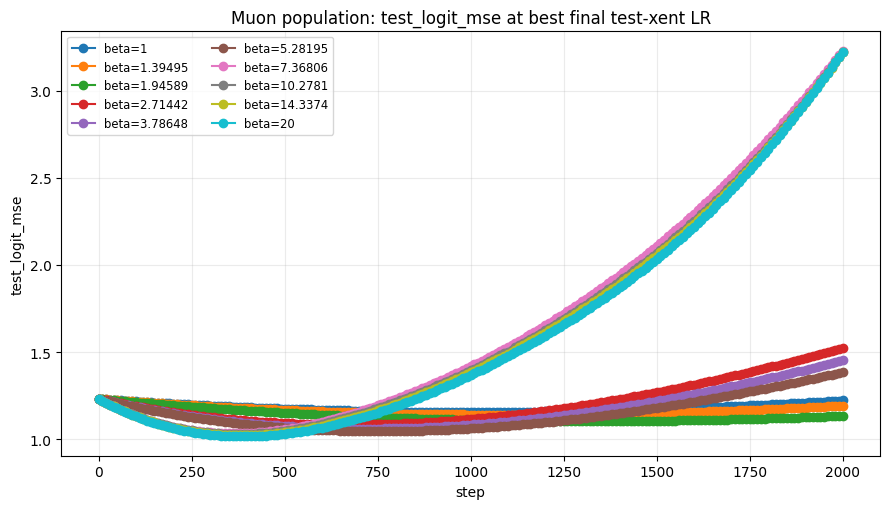

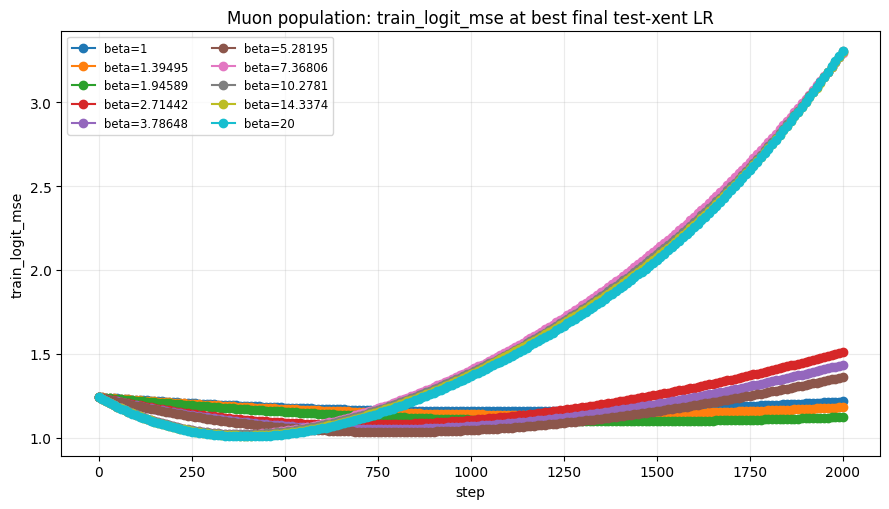

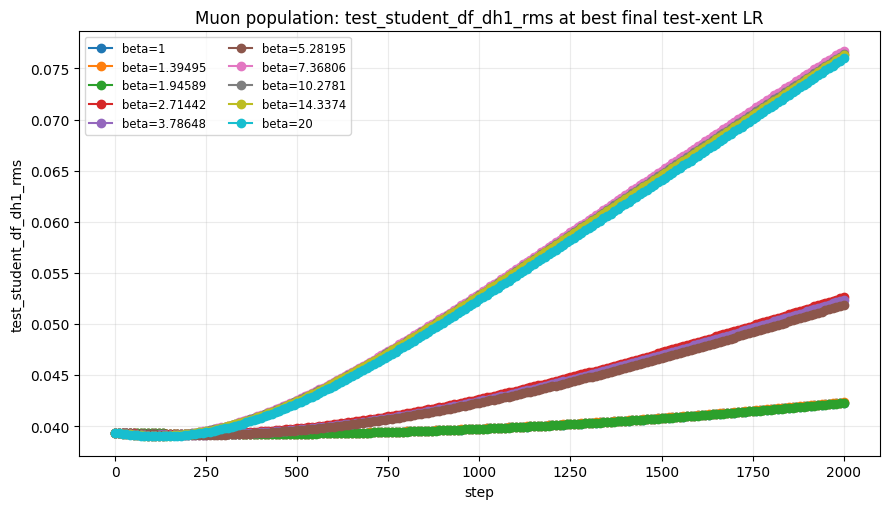

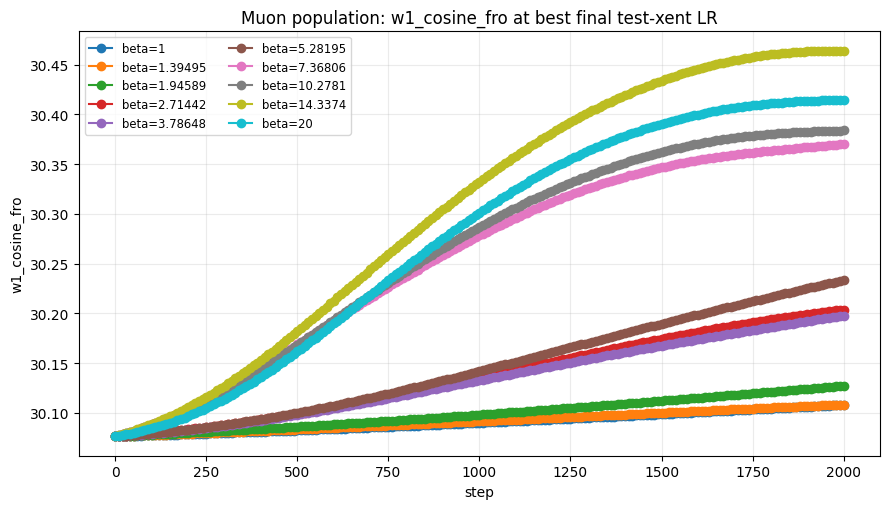

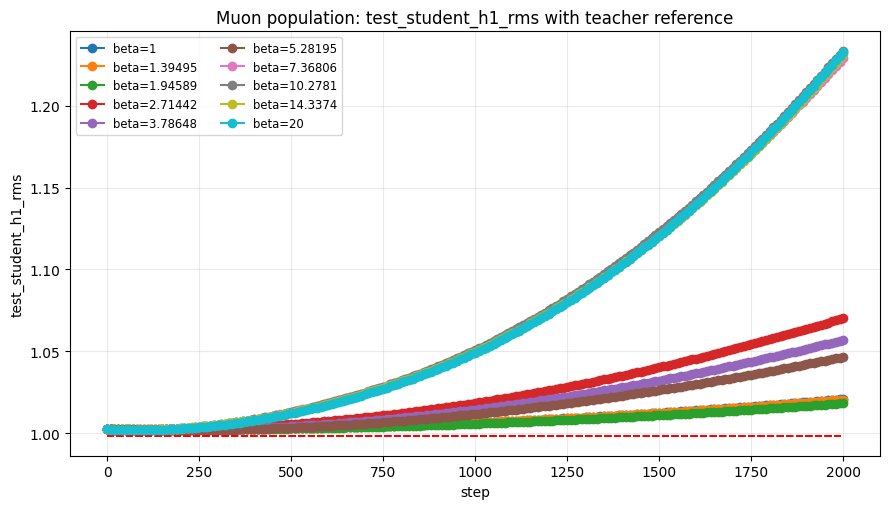

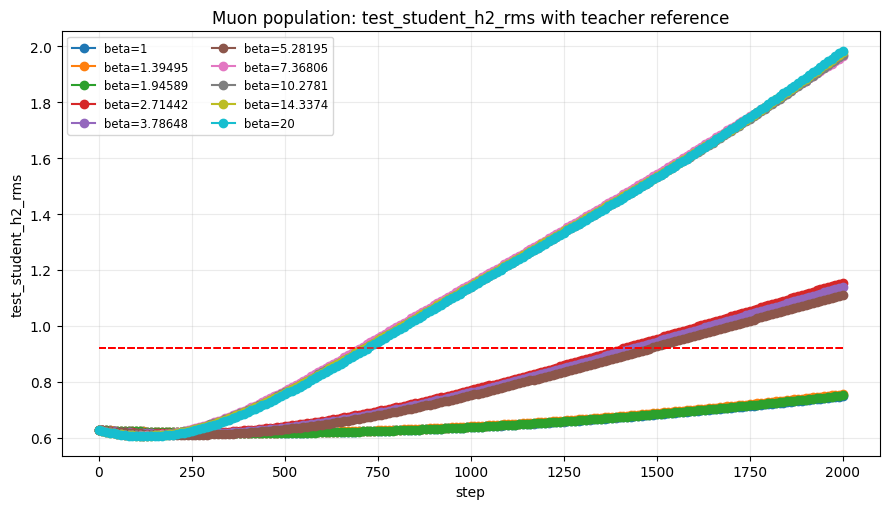

In [4]:
for optimizer in optimizer_order:
    for mode in modes:
        ts = best_lr_timeseries(df, best, optimizer, mode)
        for metric in time_metrics:
            fig = plot_metric_over_time(ts, metric, optimizer, mode)
            plt.show()
        for student_metric, teacher_metric in norm_overlays:
            fig = plot_student_teacher_norm(ts, student_metric, teacher_metric, optimizer, mode)
            plt.show()


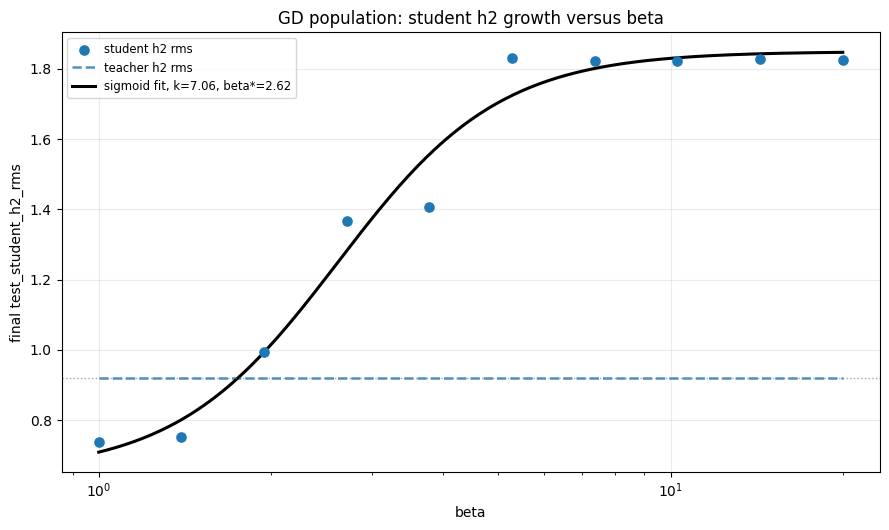

adam population: sigmoid fit failed: Optimal parameters not found: Number of calls to function has reached maxfev = 20000.


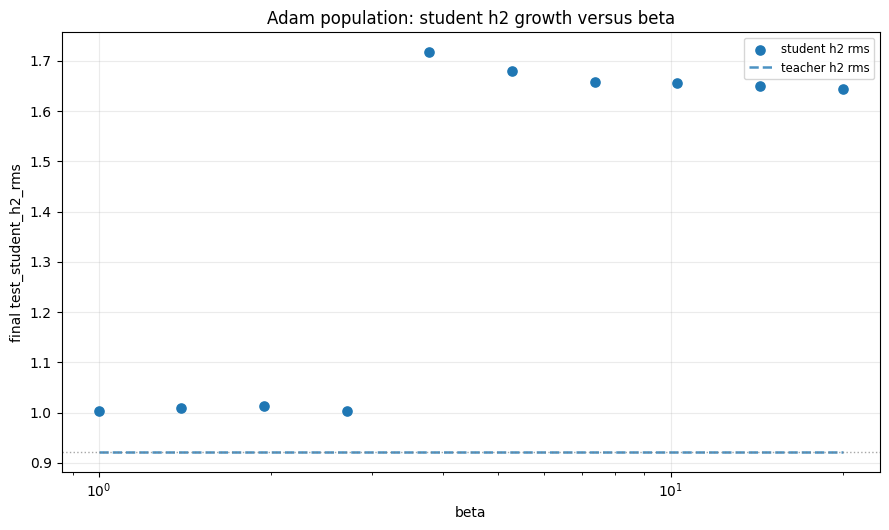

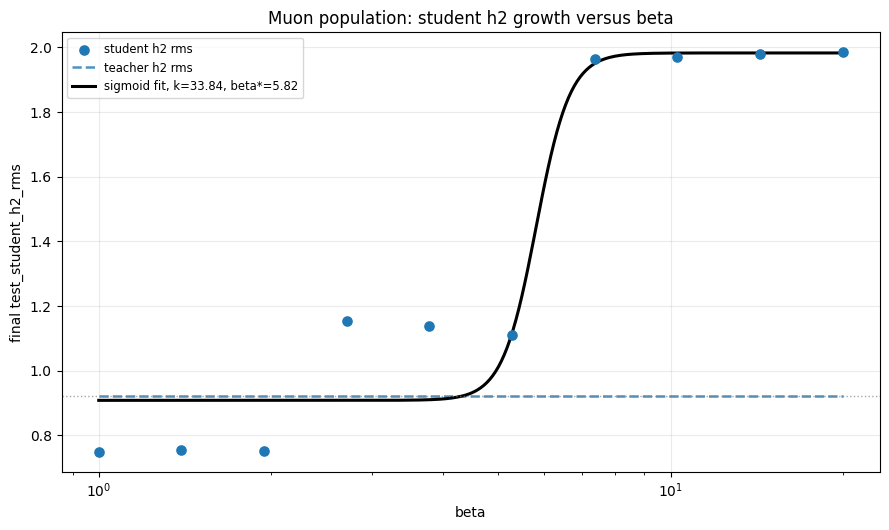

Sigmoid fit summary:


,optimizer,mode,low,high,steepness,midpoint_log10_beta,midpoint_beta,r2
0,gd,population,0.649862,1.848994,7.063323,0.418119,2.618900,0.976566
1,adam,population,NaN,NaN,NaN,NaN,NaN,NaN
2,muon,population,0.908551,1.982893,33.835429,0.764910,5.819825,0.932583


In [5]:
import numpy as np
from scipy.optimize import curve_fit
from IPython.display import display


def final_metric_by_beta(ts, metric):
    return (
        ts.sort_values('step')
        .groupby('beta', sort=True)[metric]
        .last()
        .reset_index()
    )


def sigmoid_log_beta(log_beta, low, high, steepness, midpoint):
    return low + (high - low) / (1.0 + np.exp(-steepness * (log_beta - midpoint)))


fit_rows = []

for optimizer in optimizer_order:
    for mode in modes:
        ts = best_lr_timeseries(df, best, optimizer, mode)
        h2 = final_metric_by_beta(ts, 'test_student_h2_rms')
        teacher_h2 = final_metric_by_beta(ts, 'test_teacher_h2_rms')
        merged = h2.merge(teacher_h2, on='beta', suffixes=('_student', '_teacher'))
        merged = merged.sort_values('beta').reset_index(drop=True)

        beta = merged['beta'].to_numpy(dtype=float)
        log_beta = np.log10(beta)
        student = merged['test_student_h2_rms'].to_numpy(dtype=float)
        teacher = merged['test_teacher_h2_rms'].to_numpy(dtype=float)

        low0 = float(student.min())
        high0 = float(student.max())
        midpoint0 = float(np.median(log_beta))
        steepness0 = 1.0

        try:
            popt, pcov = curve_fit(
                sigmoid_log_beta,
                log_beta,
                student,
                p0=[low0, high0, steepness0, midpoint0],
                maxfev=20000,
            )
            low_fit, high_fit, steepness_fit, midpoint_fit = popt
            student_fit = sigmoid_log_beta(log_beta, *popt)
            ss_res = float(np.sum((student - student_fit) ** 2))
            ss_tot = float(np.sum((student - student.mean()) ** 2))
            r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
            beta_midpoint = 10 ** midpoint_fit
        except Exception as exc:
            print(f'{optimizer} {mode}: sigmoid fit failed: {exc}')
            low_fit = high_fit = steepness_fit = midpoint_fit = np.nan
            beta_midpoint = np.nan
            r2 = np.nan

        fit_rows.append(
            {
                'optimizer': optimizer,
                'mode': mode,
                'low': low_fit,
                'high': high_fit,
                'steepness': steepness_fit,
                'midpoint_log10_beta': midpoint_fit,
                'midpoint_beta': beta_midpoint,
                'r2': r2,
            }
        )

        fig, ax = plt.subplots(figsize=(9, 5.4))
        ax.scatter(beta, student, s=44, label='student h2 rms', zorder=3)
        ax.plot(beta, teacher, '--', linewidth=1.8, alpha=0.8, label='teacher h2 rms')

        if np.isfinite(steepness_fit):
            beta_grid = np.logspace(np.log10(beta.min()), np.log10(beta.max()), 256)
            fit_grid = sigmoid_log_beta(np.log10(beta_grid), low_fit, high_fit, steepness_fit, midpoint_fit)
            ax.plot(beta_grid, fit_grid, color='black', linewidth=2.2, label=f'sigmoid fit, k={steepness_fit:.2f}, beta*={beta_midpoint:.3g}')

        ax.axhline(float(teacher.mean()), color='gray', linestyle=':', linewidth=1.0, alpha=0.7)
        ax.set_xscale('log')
        ax.set_xlabel('beta')
        ax.set_ylabel('final test_student_h2_rms')
        ax.set_title(f'{optimizer_labels[optimizer]} {mode}: student h2 growth versus beta')
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize='small')
        fig.tight_layout()
        fig.savefig(run_root / f'sigmoid_student_h2_{optimizer}_{mode}.png', dpi=180)
        plt.show()

fit_df = pd.DataFrame(fit_rows)
print('Sigmoid fit summary:')
display(fit_df)


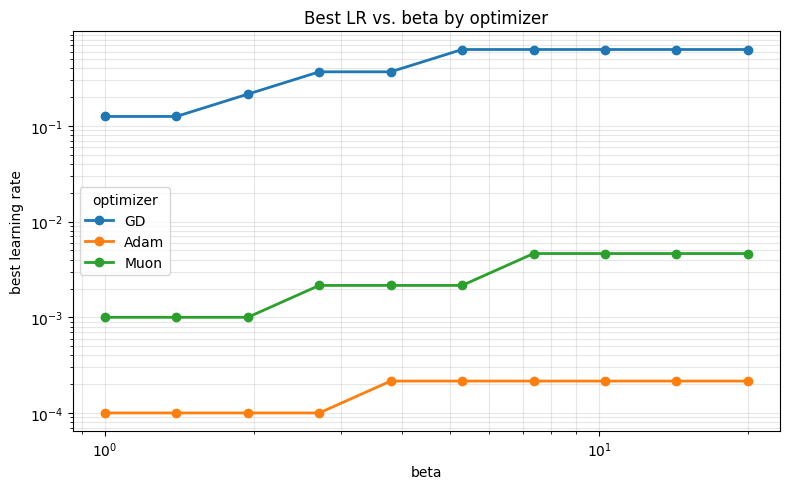

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

for optimizer in optimizer_order:
    optimizer_best = best[
        (best['optimizer'] == optimizer) & (best['mode'] == 'population')
    ].sort_values('beta')
    ax.plot(
        optimizer_best['beta'],
        optimizer_best['lr'],
        marker='o',
        linewidth=2,
        label=optimizer_labels[optimizer],
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('best learning rate')
ax.set_title('Best LR vs. beta by optimizer')
ax.grid(True, which='both', alpha=0.3)
ax.legend(title='optimizer')
fig.tight_layout()

fig.savefig(run_root / 'best_lr_vs_beta_optimizers.png', dpi=180)
plt.show()


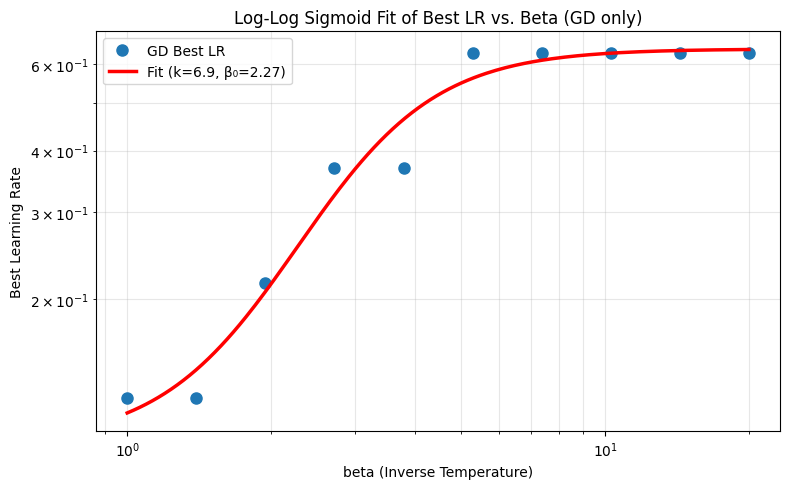

Low beta LR saturation:  0.101
High beta LR saturation: 0.644
Transition midpoint (β): 2.27


In [24]:
import numpy as np
from scipy.optimize import curve_fit

if 'optimizer' in best.columns:
    gd_best = best[(best['optimizer'] == 'gd') & (best['mode'] == 'population')].sort_values('beta')
else:
    gd_best = (
        df[(df['optimizer'] == 'gd') & (df['mode'] == 'population')]
        .sort_values(['beta', 'step'])
        .groupby(['beta', 'lr'], as_index=False)
        .last()
        .sort_values(['beta', 'test_xent'])
        .groupby('beta', as_index=False)
        .first()
        .sort_values('beta')
    )

# 1. Extract data and convert to log space
x_data = np.log10(gd_best['beta'].to_numpy(dtype=float))
y_data = np.log10(gd_best['lr'].to_numpy(dtype=float))

# 2. Define the log-log sigmoid
def log_log_sigmoid(log_x, log_y_min, log_y_max, k, log_x0):
    return log_y_min + (log_y_max - log_y_min) / (1.0 + np.exp(-k * (log_x - log_x0)))

# 3. Initial guesses (min y, max y, steepness, midpoint x)
p0 = [y_data.min(), y_data.max(), 5.0, np.median(x_data)]

# 4. Fit the curve
popt, pcov = curve_fit(log_log_sigmoid, x_data, y_data, p0=p0, maxfev=10000)
log_y_min_fit, log_y_max_fit, k_fit, log_x0_fit = popt

# 5. Generate smooth curve for plotting
beta_smooth = np.logspace(np.log10(gd_best['beta'].min()), np.log10(gd_best['beta'].max()), 200)
log_beta_smooth = np.log10(beta_smooth)
log_lr_smooth = log_log_sigmoid(log_beta_smooth, *popt)
lr_smooth = 10 ** log_lr_smooth

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gd_best['beta'], gd_best['lr'], marker='o', linestyle='', markersize=8, label='GD Best LR')
ax.plot(beta_smooth, lr_smooth, 'r-', linewidth=2.5, 
        label=f'Fit (k={k_fit:.1f}, β₀={10**log_x0_fit:.2f})')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('beta (Inverse Temperature)')
ax.set_ylabel('Best Learning Rate')
ax.set_title('Log-Log Sigmoid Fit of Best LR vs. Beta (GD only)')
ax.grid(True, which='both', alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(run_root / 'best_lr_vs_beta_gd_fit.png', dpi=180)
plt.show()

print(f"Low beta LR saturation:  {10**log_y_min_fit:.3g}")
print(f"High beta LR saturation: {10**log_y_max_fit:.3g}")
print(f"Transition midpoint (β): {10**log_x0_fit:.3g}")

### Analytical form of the Learning Rate Transition

The fitted curve is a logistic sigmoid in log-log space:
$$ \log_{10}(\text{LR}) = \log_{10}(\text{LR}_{\text{min}}) + \frac{\log_{10}(\text{LR}_{\text{max}}) - \log_{10}(\text{LR}_{\text{min}})}{1 + \exp(-k (\log_{10}(\beta) - \log_{10}(\beta_0)))} $$

When exponentiated back into standard, linear coordinates, this takes the form of a stretched geometric interpolation between the asymptotic bounds $\text{LR}_{\text{min}}$ and $\text{LR}_{\text{max}}$:

$$ \text{LR}(\beta) = \text{LR}_{\text{min}} \left( \frac{\text{LR}_{\text{max}}}{\text{LR}_{\text{min}}} \right)^{ \sigma\left(k \log_{10}\left(\frac{\beta}{\beta_0}\right) \right) } $$

where $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the standard logistic function.

Alternatively, expressing it entirely without explicit exponentials or sigmoids:

$$ \text{LR}(\beta) = \text{LR}_{\text{min}} \cdot \left( \frac{\text{LR}_{\text{max}}}{\text{LR}_{\text{min}}} \right)^{\frac{1}{1 + \left( \frac{\beta}{\beta_0} \right)^{-k / \ln 10}}} $$

At the transition midpoint $\beta = \beta_0$, the optimal learning rate is precisely the geometric mean of the boundaries: $\text{LR}(\beta_0) = \sqrt{\text{LR}_{\text{min}} \cdot \text{LR}_{\text{max}}}$.

In [ ]:
from IPython.display import Markdown

k_val = round(k_fit, 1)
lr_min_val = round(10**log_y_min_fit, 3)
lr_max_val = round(10**log_y_max_fit, 3)
beta_0_val = round(10**log_x0_fit, 2)

display(Markdown(f"""### GD Fitted Values

Plugging in the empirical parameters from the GD best-learning-rate curve fit:

- $\\text{{LR}}_{{\\text{{min}}}} \\approx {lr_min_val}$
- $\\text{{LR}}_{{\\text{{max}}}} \\approx {lr_max_val}$
- $\\beta_0 \\approx {beta_0_val}$
- $k \\approx {k_val}$

$$ \\text{{LR}}(\\beta) = {lr_min_val} \\cdot \\left( \\frac{{{lr_max_val}}}{{{lr_min_val}}} \\right)^{{\\frac{{1}}{{1 + \\left( \\frac{{\\beta}}{{{beta_0_val}}} \\right)^{{-{k_val} / \\ln 10}}}}}} $$

This represents a transition between an exploration phase dominated by optimal alignment of logits directly scaled to teacher logits, and phase transition where temperature dampens explicit matching dynamics.
"""))

### GD Fitted Values

Plugging in the empirical parameters from the GD best-learning-rate curve fit:

- $\text{LR}_{\text{min}} \approx 0.101$
- $\text{LR}_{\text{max}} \approx 0.644$
- $\beta_0 \approx 2.27$
- $k \approx 6.9$

$$ \text{LR}(\beta) = 0.101 \cdot \left( \frac{0.644}{0.101} \right)^{\frac{1}{1 + \left( \frac{\beta}{2.27} \right)^{-6.9 / \ln 10}}} $$

This represents a transition between an exploration phase dominated by optimal alignment of logits directly scaled to teacher logits, and phase transition where temperature dampens explicit matching dynamics.
